# Projeto Airbnb Rio - Ferramenta de Previsão de Preço de Imóvel para pessoas comuns 

### Objetivo

Construir um modelo de previsão de preço que permita uma pessoa comum que possui um imóvel possa saber quanto deve cobrar pela diária do seu imóvel.

Ou ainda, para o locador comum, dado o imóvel que ele está buscando, ajudar a saber se aquele imóvel está com preço atrativo (abaixo da média para imóveis com as mesmas características) ou não.

### O que temos disponível, inspirações e créditos

As bases de dados foram retiradas do site kaggle: https://www.kaggle.com/allanbruno/airbnb-rio-de-janeiro

### Expectativas Iniciais

- Acredito que a sazonalidade pode ser um fator importante, visto que meses como dezembro costumam ser bem caros no RJ
- A localização do imóvel deve fazer muita diferença no preço, já que no Rio de Janeiro a localização pode mudar completamente as características do lugar (segurança, beleza natural, pontos turísticos)
- Adicionais/Comodidades podem ter um impacto significativo, visto que temos muitos prédios e casas antigos no Rio de Janeiro.

### Importar Bibliotecas

In [2]:
import pandas as pd
import pathlib
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Consolidar Base de Dados

In [3]:
meses = {'jan': 1, 'fev':2, 'mar':3, 'abr': 4, 'mai':5, 'jun': 6, 'jul': 7, 'ago': 8, 'set': 9, 'out': 10, 'nov': 11, 'dez': 12}
caminho_base = pathlib.Path('dataset')

lista_final = [] # Use um nome diferente para evitar conflitos

# Verifique se a pasta existe
if not caminho_base.exists():
    print("Erro: A pasta 'dataset' não foi encontrada!")
else:
    for arquivo in caminho_base.iterdir():
        if arquivo.suffix == '.csv':
            print(f"Processando: {arquivo.name}") # Confirma que o arquivo foi lido
            
            # Extração
            nome_mes = arquivo.name[:3]
            mes = meses.get(nome_mes) # .get evita erro se o nome for diferente
            
            ano = arquivo.name[-8:]
            ano = int(ano.replace(".csv", ""))

            # Leitura
            df_temp = pd.read_csv(arquivo)
            
            # CRIAÇÃO DAS COLUNAS
            df_temp['ano'] = ano
            df_temp['mes'] = mes
            
            # Verificação imediata
            if 'ano' in df_temp.columns:
                print(f"   -> Colunas mes/ano criadas no DF temporário.")
            
            lista_final.append(df_temp)

    # Concatenação final
    if lista_final:
        base = pd.concat(lista_final, ignore_index=True)
        print("\n--- SUCESSO ---")
        print(f"Colunas finais no DF 'base': {base.columns.tolist()}")
        print(base[['mes', 'ano']].head()) # Mostra as primeiras linhas das colunas novas
    else:
        print("\n--- ERRO ---")
        print("Nenhum arquivo CSV foi processado. Verifique os nomes dos arquivos.")

Processando: abril2018.csv


C:\Users\Andre\AppData\Local\Temp\ipykernel_2436\224946130.py:22: DtypeWarning: Columns (0: monthly_price, 1: license) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(arquivo)


   -> Colunas mes/ano criadas no DF temporário.
Processando: abril2019.csv


C:\Users\Andre\AppData\Local\Temp\ipykernel_2436\224946130.py:22: DtypeWarning: Columns (0: weekly_price, 1: monthly_price, 2: license) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(arquivo)


   -> Colunas mes/ano criadas no DF temporário.
Processando: abril2020.csv


...

   -> Colunas mes/ano criadas no DF temporário.
Processando: setembro2018.csv


C:\Users\Andre\AppData\Local\Temp\ipykernel_2436\224946130.py:22: DtypeWarning: Columns (0: license) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(arquivo)


   -> Colunas mes/ano criadas no DF temporário.
Processando: setembro2019.csv


C:\Users\Andre\AppData\Local\Temp\ipykernel_2436\224946130.py:22: DtypeWarning: Columns (0: weekly_price, 1: monthly_price, 2: license) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(arquivo)


   -> Colunas mes/ano criadas no DF temporário.

--- SUCESSO ---
Colunas finais no DF 'base': ['id', 'listing_url', 'scrape_id', 'last_scraped', 'name', 'summary', 'space', 'description', 'experiences_offered', 'neighborhood_overview', 'notes', 'transit', 'access', 'interaction', 'house_rules', 'thumbnail_url', 'medium_url', 'picture_url', 'xl_picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'street', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'city', 'state', 'zipcode', 'market', 'smart_location', 'country_code', 'country', 'latitude', 'longitude', 'is_location_exact', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bedrooms

### Remover todas as colunas que contenham links (url)

In [4]:
# Identifica colunas que contêm 'url'
remover = [coluna for coluna in base.columns if 'url' in coluna.lower()]

# Deleta as colunas encontradas
base.drop(columns=remover, inplace=True)

print(f"Colunas removidas: {remover}")

Colunas removidas: ['listing_url', 'thumbnail_url', 'medium_url', 'picture_url', 'xl_picture_url', 'host_url', 'host_thumbnail_url', 'host_picture_url']


### Remover todas as colunas que contenham ID

In [5]:
remover = [coluna for coluna in base.columns if 'id' in coluna.lower()]

# Deleta as colunas encontradas
base.drop(columns=remover, inplace=True)

print(f"Colunas removidas: {remover}")

base.info(verbose=True, show_counts=True)

Colunas removidas: ['id', 'scrape_id', 'host_id', 'host_identity_verified']
<class 'pandas.DataFrame'>
RangeIndex: 902210 entries, 0 to 902209
Data columns (total 96 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   last_scraped                                  902210 non-null  str    
 1   name                                          900538 non-null  str    
 2   summary                                       860406 non-null  str    
 3   space                                         543496 non-null  str    
 4   description                                   884040 non-null  str    
 5   experiences_offered                           902210 non-null  str    
 6   neighborhood_overview                         481672 non-null  str    
 7   notes                                         284885 non-null  str    
 8   transit                                       476428 non-nu

### Remover colunas com muitas NAN

In [6]:
# Verifica a porcentagem de nulos por coluna
nulos = base.isnull().mean() * 100
colunas_muitos_nulos = nulos[nulos > 50].index.tolist()


# 2. Exclui do DataFrame
base = base.drop(columns=colunas_muitos_nulos)

# 3. Verifica o novo tamanho do DataFrame
print(f"Foram removidas {(colunas_muitos_nulos)} colunas.")
print(f"Novo formato do DataFrame: {base.shape}")

Foram removidas ['notes', 'access', 'interaction', 'host_about', 'host_acceptance_rate', 'neighbourhood_group_cleansed', 'square_feet', 'weekly_price', 'monthly_price', 'license', 'jurisdiction_names'] colunas.
Novo formato do DataFrame: (902210, 85)


### Remover colunas com valor único (todos iguais)

In [8]:
# Identifica colunas que têm apenas 1 valor único
colunas_inuteis = [col for col in base.columns if base[col].nunique() <= 1]

# 2. Exclui do DataFrame
base = base.drop(columns=colunas_inuteis)

# 3. Verifica o novo tamanho do DataFrame
print(f"Foram removidas {(colunas_inuteis)} colunas.")
print(f"Novo formato do DataFrame: {base.shape}")

Foram removidas ['experiences_offered', 'has_availability', 'requires_license', 'is_business_travel_ready'] colunas.
Novo formato do DataFrame: (902210, 81)


In [9]:
base.info(verbose=True, show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 902210 entries, 0 to 902209
Data columns (total 81 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   last_scraped                                  902210 non-null  str    
 1   name                                          900538 non-null  str    
 2   summary                                       860406 non-null  str    
 3   space                                         543496 non-null  str    
 4   description                                   884040 non-null  str    
 5   neighborhood_overview                         481672 non-null  str    
 6   transit                                       476428 non-null  str    
 7   house_rules                                   457813 non-null  str    
 8   host_name                                     901750 non-null  str    
 9   host_since                                    901750 non-nu

### Ver colunas no excel

In [10]:
base.head(500).to_csv('verificar_colunas.csv', sep=';')

### Remover uma lista de colunas selecionadas manualmente

In [11]:
colunas_para_remover = ['last_scraped', 'name', 'summary','host_name', 'host_since', 'host_location', 'host_response_time', 'host_response_rate', 'host_total_listings_count', 'host_verifications','city', 'state', 'zipcode', 'country', 'description','host_has_profile_pic', 'street', 'neighbourhood', 'neighbourhood_cleansed', 'market', 'smart_location', 'country_code', 'is_location_exact', 'require_guest_profile_picture', 'require_guest_profile_picture', 'calendar_updated', 'availability_30', 'availability_60', 'availability_90', 'availability_365']
base = base.drop(columns=colunas_para_remover)

# 3. Verifica o novo tamanho do DataFrame
print(f"Foram removidas {(colunas_para_remover)} colunas.")
print(f"Novo formato do DataFrame: {base.shape}")

Foram removidas ['last_scraped', 'name', 'summary', 'host_name', 'host_since', 'host_location', 'host_response_time', 'host_response_rate', 'host_total_listings_count', 'host_verifications', 'city', 'state', 'zipcode', 'country', 'description', 'host_has_profile_pic', 'street', 'neighbourhood', 'neighbourhood_cleansed', 'market', 'smart_location', 'country_code', 'is_location_exact', 'require_guest_profile_picture', 'require_guest_profile_picture', 'calendar_updated', 'availability_30', 'availability_60', 'availability_90', 'availability_365'] colunas.
Novo formato do DataFrame: (902210, 52)


### Tratar Valores Faltando

In [12]:
print(base.isna().sum())   # mostre o somatório de linhas com valores vazios para cada coluna

space                                           358714
neighborhood_overview                           420538
transit                                         425782
house_rules                                     444397
host_is_superhost                                  460
host_neighbourhood                              346612
host_listings_count                                460
latitude                                             0
longitude                                            0
property_type                                        0
room_type                                            0
accommodates                                         0
bathrooms                                         1724
bedrooms                                           850
beds                                              2502
bed_type                                             0
amenities                                            0
price                                                0
security_d

In [13]:
# Exclui colunas com mais de 50% (300 mil) valores nulos

for coluna in base:
    if base[coluna].isna().sum() > 300000:
        base = base.drop(coluna, axis = 1)

# 3. Verifica o novo tamanho do DataFrame
print(f"Novo formato do DataFrame: {base.shape}")

Novo formato do DataFrame: (902210, 25)


### Excluir linhas com valores vazios em pelo menos 3 colunas

In [14]:
# cria uma nova coluna com a contagem de NaNs por linha
base['total_nan_na_linha'] = base.isna().sum(axis=1)

# Pega os índices das linhas que têm mais de 2 NaNs
indices_para_excluir = base[base['total_nan_na_linha'] > 3].index

# Exclui essas linhas pelo índice
base = base.drop(indices_para_excluir)

# Exclui a coluna criada no inicio  para contagem de nanas por linha
base = base.drop(columns = ['total_nan_na_linha'])

print(f"Novo formato do DataFrame: {base.shape}")

Novo formato do DataFrame: (902208, 25)


In [15]:
# Excluir linhas que tenham valor nan

base = base.dropna()
print(f"Novo formato do DataFrame: {base.shape}")

Novo formato do DataFrame: (897709, 25)


### Verificar Tipos de Dados em cada coluna

In [16]:
print(base.dtypes)



host_is_superhost                       str
host_listings_count                 float64
latitude                            float64
longitude                           float64
property_type                           str
room_type                               str
accommodates                          int64
bathrooms                           float64
bedrooms                            float64
beds                                float64
bed_type                                str
amenities                               str
price                                   str
guests_included                       int64
extra_people                            str
minimum_nights                        int64
maximum_nights                        int64
calendar_last_scraped                   str
number_of_reviews                     int64
instant_bookable                        str
cancellation_policy                     str
require_guest_phone_verification        str
calculated_host_listings_count  

In [17]:
print(base.iloc[0])

host_is_superhost                                                                   f
host_listings_count                                                               1.0
latitude                                                                   -22.946854
longitude                                                                  -43.182737
property_type                                                               Apartment
room_type                                                             Entire home/apt
accommodates                                                                        4
bathrooms                                                                         1.0
bedrooms                                                                          0.0
beds                                                                              2.0
bed_type                                                                     Real Bed
amenities                           {TV,Internet,"Air 

### Transformando valores de string para float

In [18]:
base['price'] = base['price'].str.replace('$',"")
base['price'] = base['price'].str.replace(',',"")
base['price'] = base['price'].astype(np.float32, copy=False)

base['extra_people'] = base['extra_people'].str.replace('$',"")
base['extra_people'] = base['extra_people'].str.replace(',',"")
base['extra_people'] = base['extra_people'].astype(np.float32, copy=False)

C:\Users\Andre\AppData\Local\Temp\ipykernel_2436\2137548055.py:3: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  base['price'] = base['price'].astype(np.float32, copy=False)
C:\Users\Andre\AppData\Local\Temp\ipykernel_2436\2137548055.py:7: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  base['extra_people'] = base['extra_people'].astype(np.float32, copy=False)


### Análise Exploratória e Tratar Outliers

### Outliers
#### amplitude = Q3 - Q1
#### limite inferior = Q1 - 1,5 * amplitude  (abixo disso, é outlier)
#### limite superior = Q3 + 1,5 * amplitude (acima disso é outlier)


<Axes: >

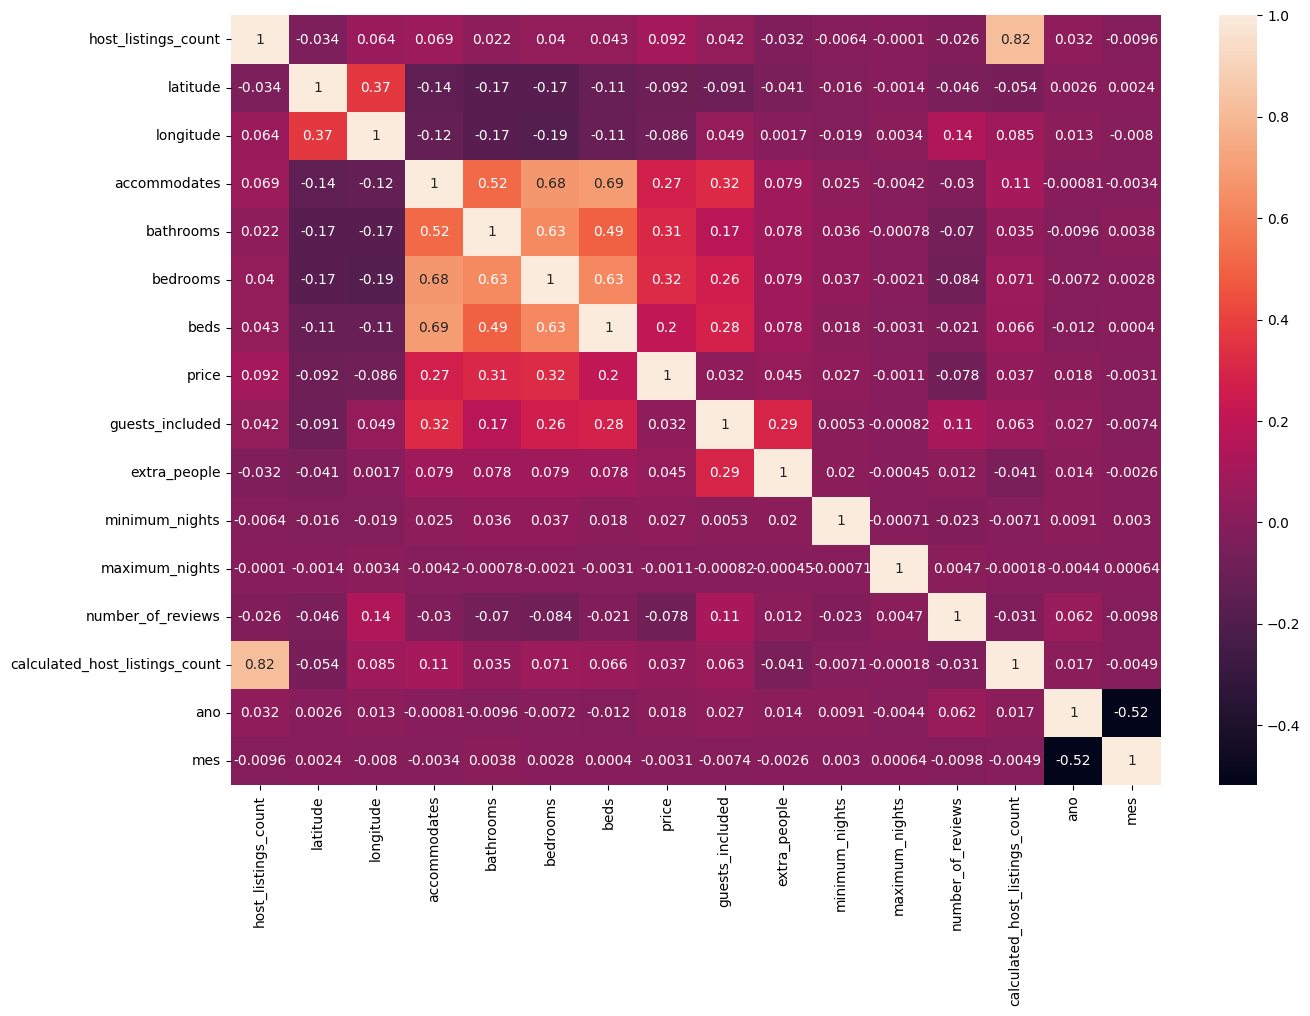

In [21]:
# Correlação
plt.figure(figsize=(15,10))
sns.heatmap(base.corr(numeric_only=True), annot=True)


In [28]:
def limites(coluna):
    q1 = coluna.quantile(0.25)
    q3 = coluna.quantile(0.75)
    amplitude = q3 - q1
    return q1 - 1.5*amplitude , q3 + 1.5 * amplitude


In [48]:
def diagrama_caixa(coluna):
    fig, (ax1, ax2) = plt.subplots(1,2)
    fig.set_size_inches(15,5)
    sns.boxplot(x=coluna, ax=ax1)
    ax2.set_xlim(limites(coluna))
    sns.boxplot(x=coluna, ax=ax2)


def histograma(coluna):
    plt.figure(figsize =(15, 5))
    sns.histplot(coluna, kde=True)
    

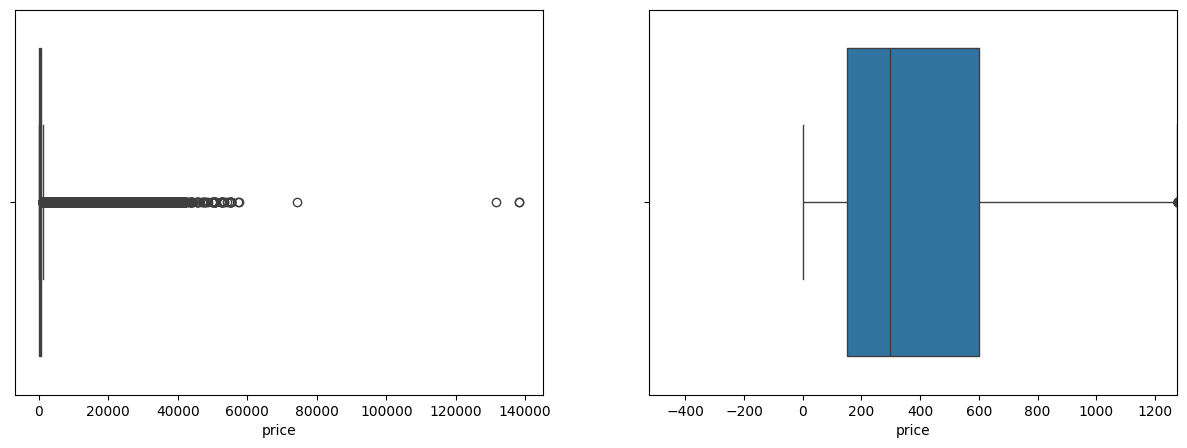

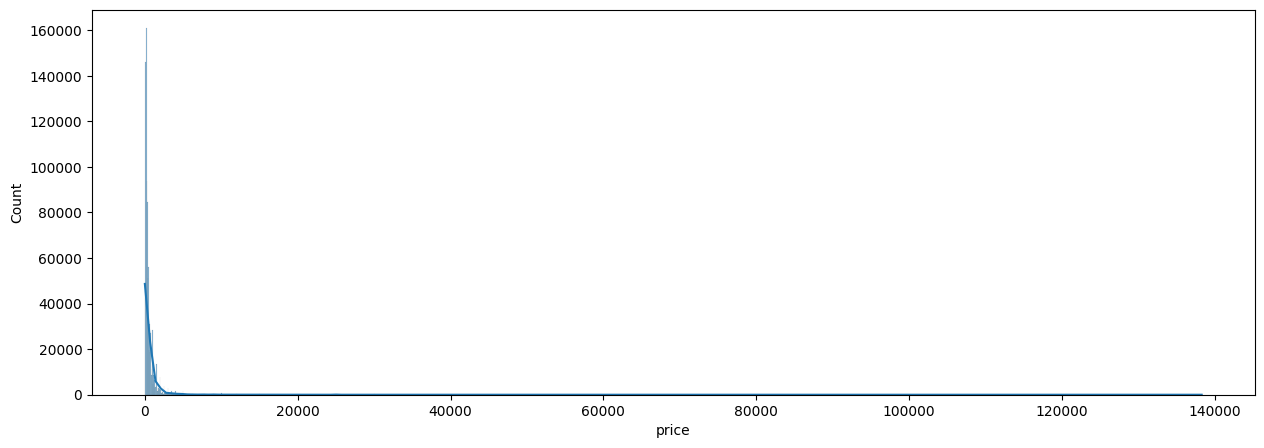

In [49]:
diagrama_caixa(base['price'])
histograma(base['price'])

### Encoding

### Modelo de Previsão

### Análise do Melhor Modelo

### Ajustes e Melhorias no Melhor Modelo